In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Clustering algorithms
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ============================================================
# PHASE 1: LOAD AND INSPECT THE DATA
# ============================================================

# Load the dataset
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Basic inspection
print("Shape of dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (374, 13)

Column Names:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

First 5 rows:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
# ============================================================
# PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Data types and non-null counts
print("Dataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB
None

Summary Statistic

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [5]:
# ============================================================
# PHASE 3: DATA CLEANING
# ============================================================

# Check missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Check unique values in categorical columns
print("\nUnique values in Sleep Disorder:", df['Sleep Disorder'].unique())
print("Unique values in Gender:", df['Gender'].unique())
print("Unique values in BMI Category:", df['BMI Category'].unique())
print("Unique values in Occupation:", df['Occupation'].unique())

# Check duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing Values per Column:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Unique values in Sleep Disorder: <StringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str
Unique values in Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique values in BMI Category: <StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str
Unique values in Occupation: <StringArray>
[   'Software Engineer',               'Doctor', 'Sales Representative',
              'Teacher',                'Nurse',             'Engineer',
           'Accountant',            'Scientist',               'Law

In [6]:
# ============================================================
# DATA CLEANING
# ============================================================

# 1. Fill missing Sleep Disorder values with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Fix BMI Category inconsistency ('Normal' and 'Normal Weight' are the same)
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# 3. Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# 4. Drop original Blood Pressure and Person ID columns (not needed for clustering)
df = df.drop(columns=['Blood Pressure', 'Person ID'])

# Confirm cleaning
print("Cleaned dataset shape:", df.shape)
print("\nSleep Disorder values after fix:", df['Sleep Disorder'].unique())
print("BMI Category values after fix:", df['BMI Category'].unique())
print("\nMissing values after cleaning:")
print(df.isnull().sum())
df.head()

Cleaned dataset shape: (374, 13)

Sleep Disorder values after fix: <StringArray>
['None', 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str
BMI Category values after fix: <StringArray>
['Overweight', 'Normal', 'Obese']
Length: 3, dtype: str

Missing values after cleaning:
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic_BP                0
Diastolic_BP               0
dtype: int64


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [7]:
# ============================================================
# PHASE 4: DATA WRANGLING & PREPROCESSING
# ============================================================

# Save the Sleep Disorder labels separately (we'll use these later 
# to compare with our clustering results)
sleep_disorder_labels = df['Sleep Disorder'].copy()

# Encode categorical columns
le = LabelEncoder()
df_encoded = df.copy()

df_encoded['Gender'] = le.fit_transform(df['Gender'])
df_encoded['Occupation'] = le.fit_transform(df['Occupation'])
df_encoded['BMI Category'] = le.fit_transform(df['BMI Category'])
df_encoded['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])

print("Encoding complete!")
print("\nGender mapping: Male=1, Female=0")
print("Sleep Disorder unique encoded values:", df_encoded['Sleep Disorder'].unique())
print("\nEncoded dataframe sample:")
df_encoded.head()

Encoding complete!

Gender mapping: Male=1, Female=0
Sleep Disorder unique encoded values: [1 2 0]

Encoded dataframe sample:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90


In [9]:
# ============================================================
# FEATURE SCALING - Critical for clustering algorithms
# ============================================================

# Drop Sleep Disorder from features (it's our label, not a feature)
X = df_encoded.drop(columns=['Sleep Disorder'])

# Apply Standard Scaling (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Scaling complete!")
print("Shape of scaled feature matrix:", X_scaled.shape)
print("\nMean of each feature (should be ~0):")
print(X_scaled_df.mean().round(4))
print("\nStd of each feature (should be ~1):")
print(X_scaled_df.std().round(4))

✅ Scaling complete!
Shape of scaled feature matrix: (374, 12)

Mean of each feature (should be ~0):
Gender                     0.0
Age                       -0.0
Occupation                -0.0
Sleep Duration             0.0
Quality of Sleep           0.0
Physical Activity Level   -0.0
Stress Level               0.0
BMI Category              -0.0
Heart Rate                -0.0
Daily Steps               -0.0
Systolic_BP               -0.0
Diastolic_BP              -0.0
dtype: float64

Std of each feature (should be ~1):
Gender                     1.0013
Age                        1.0013
Occupation                 1.0013
Sleep Duration             1.0013
Quality of Sleep           1.0013
Physical Activity Level    1.0013
Stress Level               1.0013
BMI Category               1.0013
Heart Rate                 1.0013
Daily Steps                1.0013
Systolic_BP                1.0013
Diastolic_BP               1.0013
dtype: float64


✅ PCA complete!
Variance explained by PC1: 33.27%
Variance explained by PC2: 29.75%
Total variance explained: 63.02%


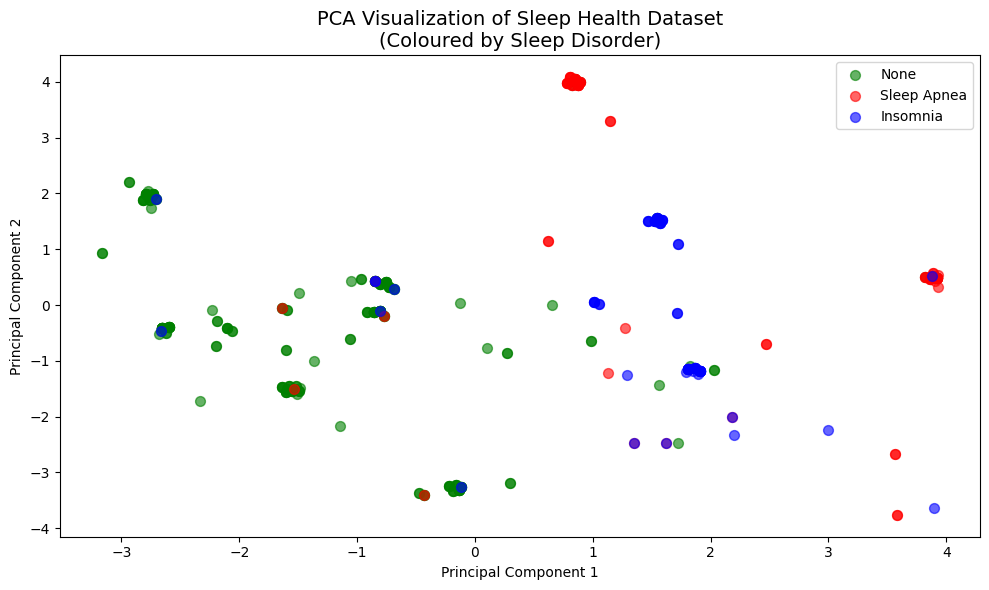

✅ PCA plot saved!


In [ ]:
# ============================================================
# PHASE 5: PCA - Reduce to 2D for visualization
# ============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("✅ PCA complete!")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Plot PCA coloured by Sleep Disorder labels
plt.figure(figsize=(10, 6))
colors = {'None': 'green', 'Sleep Apnea': 'red', 'Insomnia': 'blue'}
for label in sleep_disorder_labels.unique():
    mask = sleep_disorder_labels == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                label=label, alpha=0.6, s=50,
                color=colors[label])

plt.title('PCA Visualization of Sleep Health Dataset\n(Coloured by Sleep Disorder)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150)
plt.show()


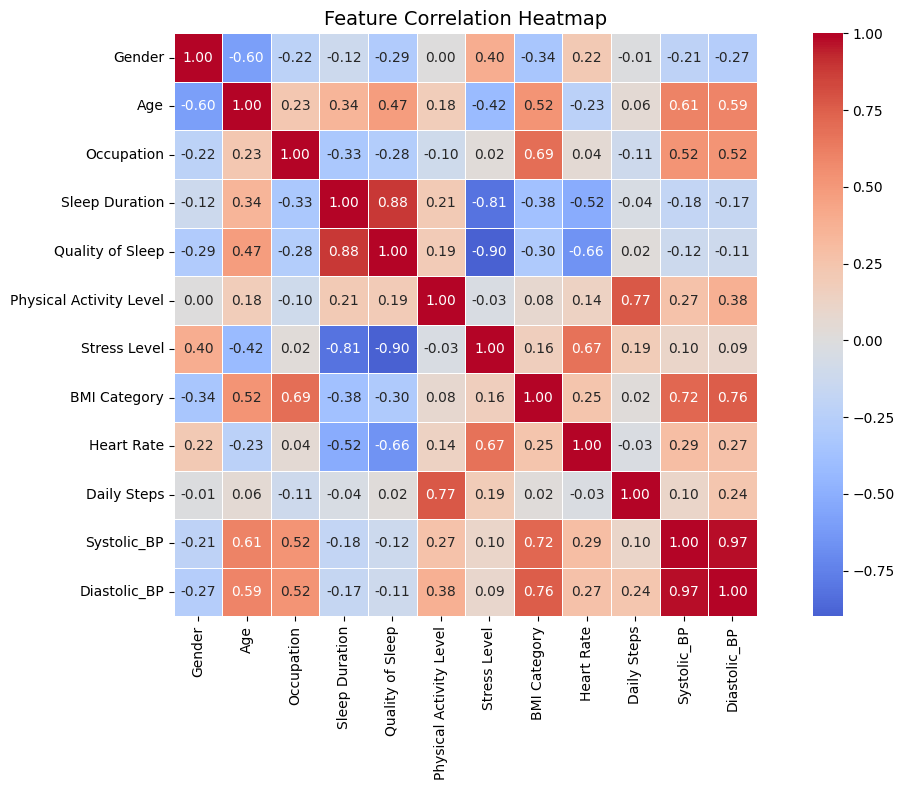

✅ Correlation heatmap saved!


In [11]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))
correlation_matrix = X_scaled_df.corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Correlation heatmap saved!")

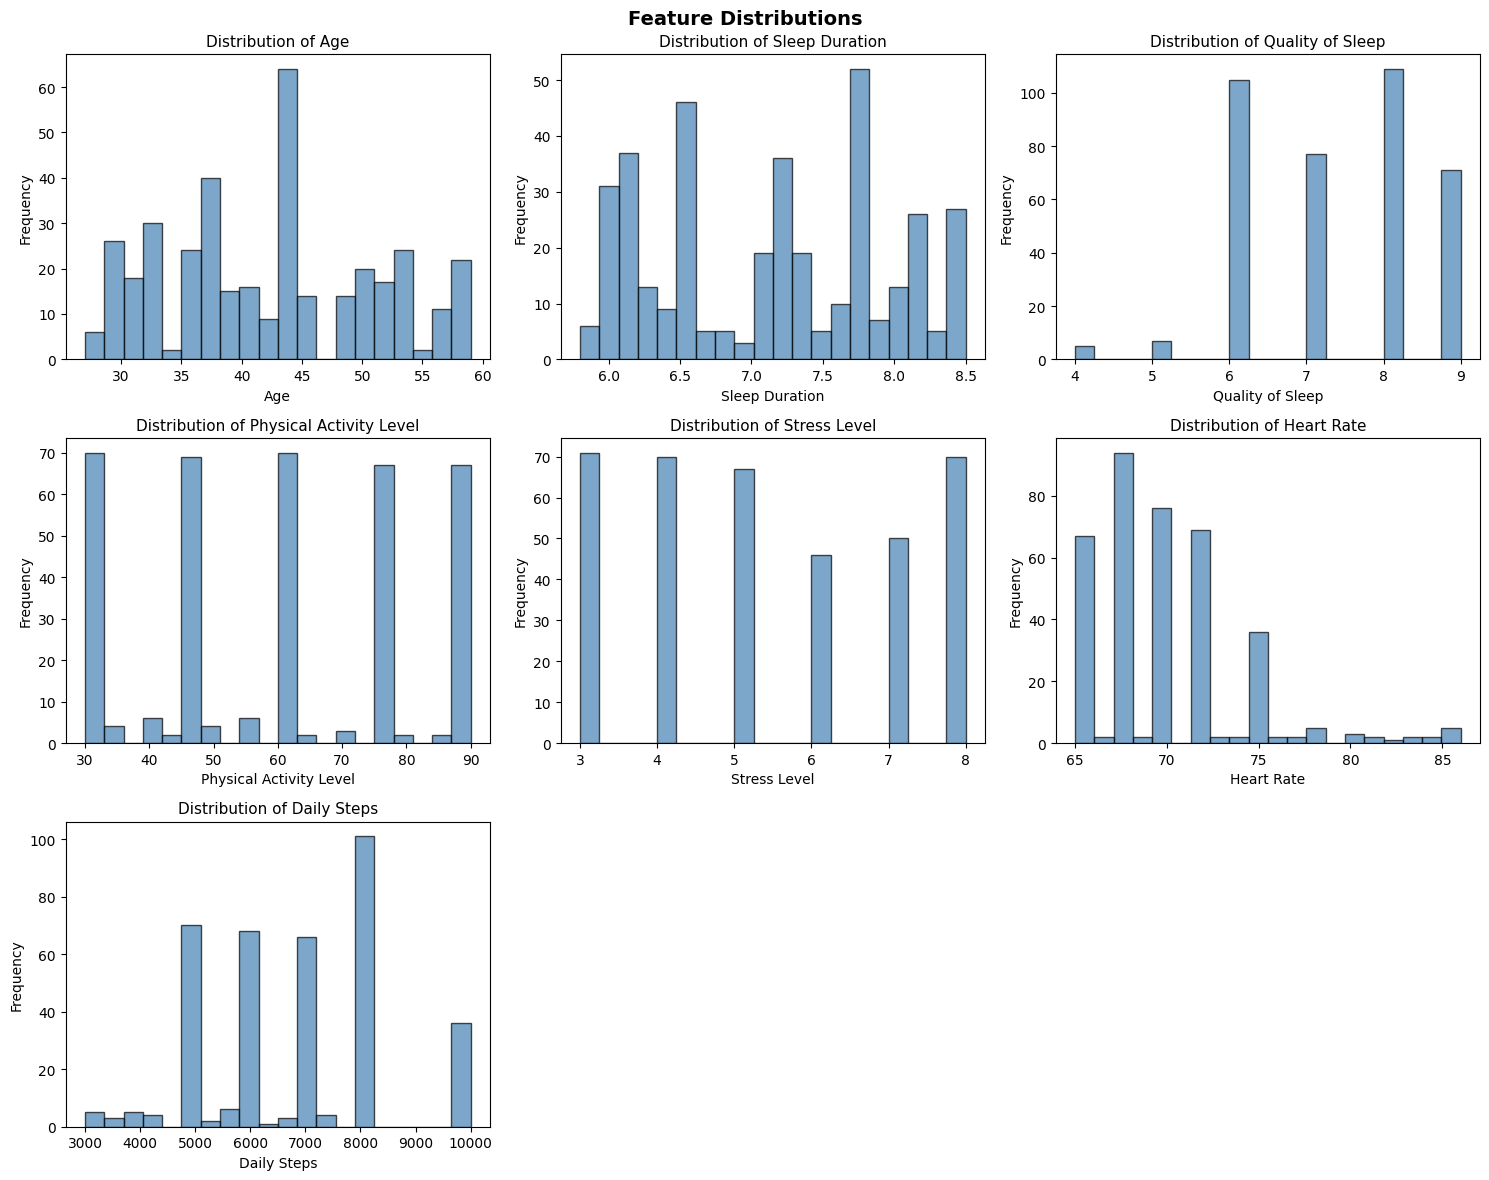

✅ Distribution plots saved!


In [12]:
# ============================================================
# DISTRIBUTION PLOTS
# ============================================================

numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 
                  'Physical Activity Level', 'Stress Level', 
                  'Heart Rate', 'Daily Steps']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()
print("✅ Distribution plots saved!")

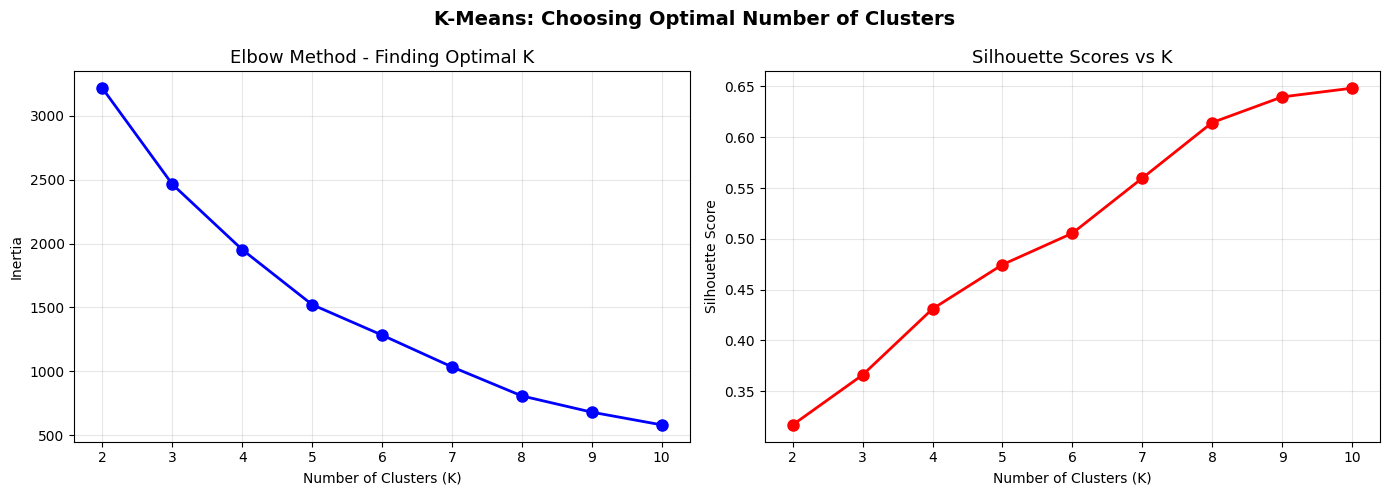

Silhouette scores for each K:
  K=2: 0.3169
  K=3: 0.3661
  K=4: 0.4311
  K=5: 0.4746
  K=6: 0.5056
  K=7: 0.5598
  K=8: 0.6145
  K=9: 0.6397
  K=10: 0.6483


In [13]:
# ============================================================
# PHASE 6: CLUSTERING - 1. K-MEANS
# ============================================================

# First find optimal number of clusters using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve + Silhouette Scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method - Finding Optimal K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Scores vs K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()

print("Silhouette scores for each K:")
for k, s in zip(K_range, silhouette_scores):
    print(f"  K={k}: {s:.4f}")

K-Means (K=3) Evaluation Metrics:
  Silhouette Score:        0.3661  (higher is better, max=1)
  Davies-Bouldin Score:    1.2293  (lower is better)
  Calinski-Harabasz Score: 152.3351  (higher is better)


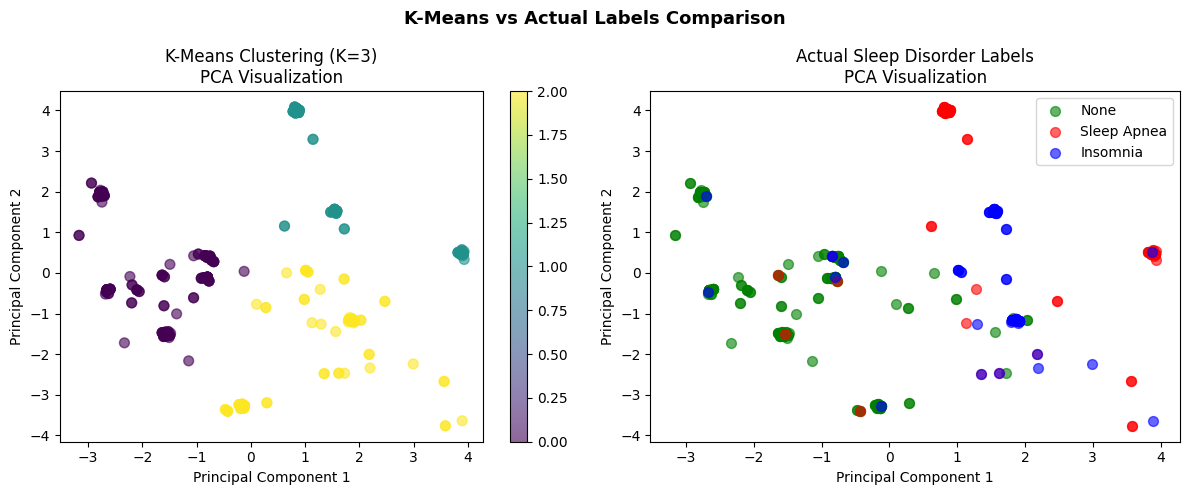

✅ K-Means clustering complete!


In [14]:
# ============================================================
# K-MEANS WITH K=3
# ============================================================

# Fit K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print("K-Means (K=3) Evaluation Metrics:")
print(f"  Silhouette Score:        {kmeans_silhouette:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Score:    {kmeans_db:.4f}  (lower is better)")
print(f"  Calinski-Harabasz Score: {kmeans_ch:.4f}  (higher is better)")

# Visualize clusters in PCA space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=kmeans_labels, cmap='viridis', 
                      alpha=0.6, s=50)
plt.colorbar(scatter)
plt.title('K-Means Clustering (K=3)\nPCA Visualization', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 2, 2)
colors = {'None': 'green', 'Sleep Apnea': 'red', 'Insomnia': 'blue'}
for label in sleep_disorder_labels.unique():
    mask = sleep_disorder_labels == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, alpha=0.6, s=50,
                color=colors[label])
plt.title('Actual Sleep Disorder Labels\nPCA Visualization', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.suptitle('K-Means vs Actual Labels Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_results.png', dpi=150)
plt.show()
print("✅ K-Means clustering complete!")

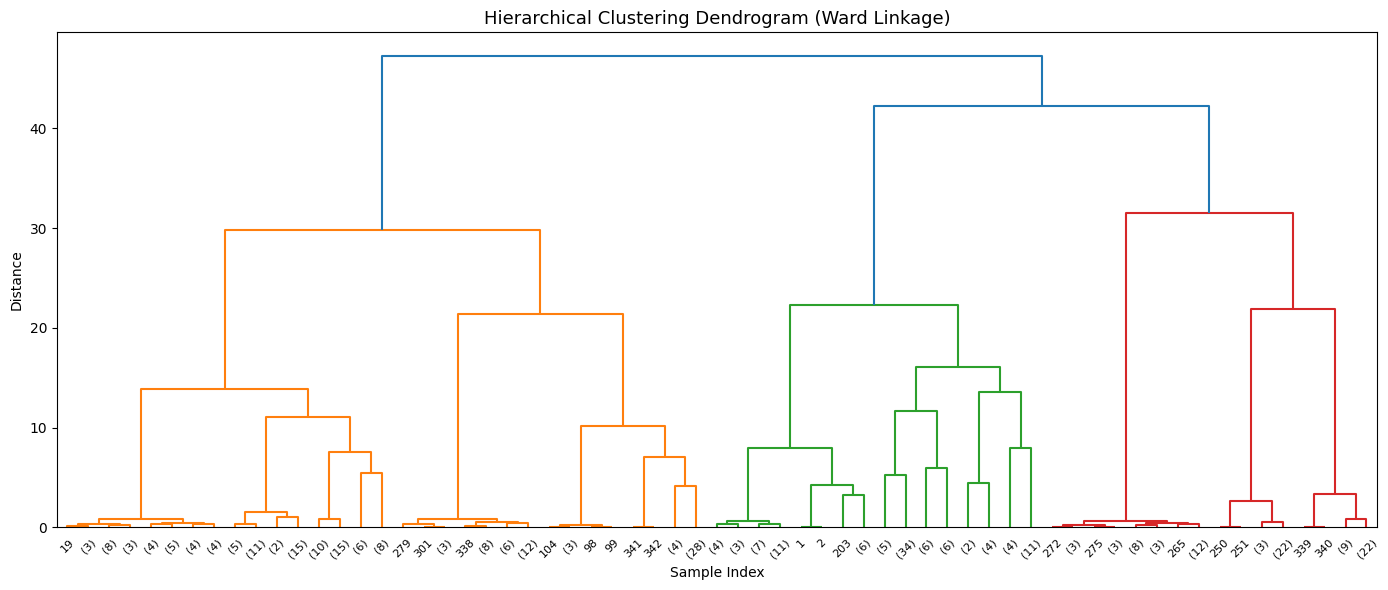

Hierarchical Clustering Evaluation Metrics:
  Silhouette Score:        0.3630
  Davies-Bouldin Score:    1.2671
  Calinski-Harabasz Score: 150.2078


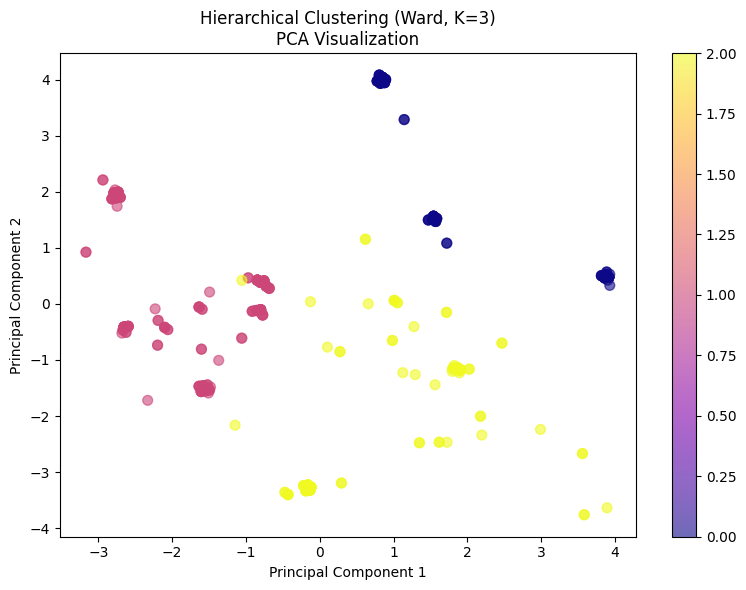

✅ Hierarchical clustering complete!


In [15]:
# ============================================================
# CLUSTERING - 2. HIERARCHICAL CLUSTERING
# ============================================================

# First plot Dendrogram to find optimal number of clusters
plt.figure(figsize=(14, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='level', p=5,
           leaf_rotation=45, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=13)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

# Fit Agglomerative Clustering with 3 clusters
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Evaluate
hier_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hier_db = davies_bouldin_score(X_scaled, hierarchical_labels)
hier_ch = calinski_harabasz_score(X_scaled, hierarchical_labels)

print("Hierarchical Clustering Evaluation Metrics:")
print(f"  Silhouette Score:        {hier_silhouette:.4f}")
print(f"  Davies-Bouldin Score:    {hier_db:.4f}")
print(f"  Calinski-Harabasz Score: {hier_ch:.4f}")

# Visualize
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=hierarchical_labels, cmap='plasma',
                      alpha=0.6, s=50)
plt.colorbar(scatter)
plt.title('Hierarchical Clustering (Ward, K=3)\nPCA Visualization', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('hierarchical_results.png', dpi=150)
plt.show()
print("✅ Hierarchical clustering complete!")

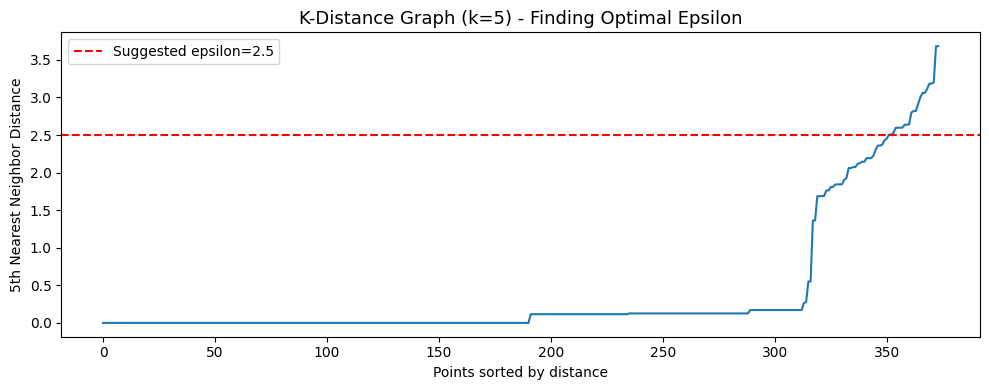

Number of clusters found: 5
Number of noise points:   18

DBSCAN Evaluation Metrics (excluding noise):
  Silhouette Score:        0.4539
  Davies-Bouldin Score:    0.6036
  Calinski-Harabasz Score: 124.8996


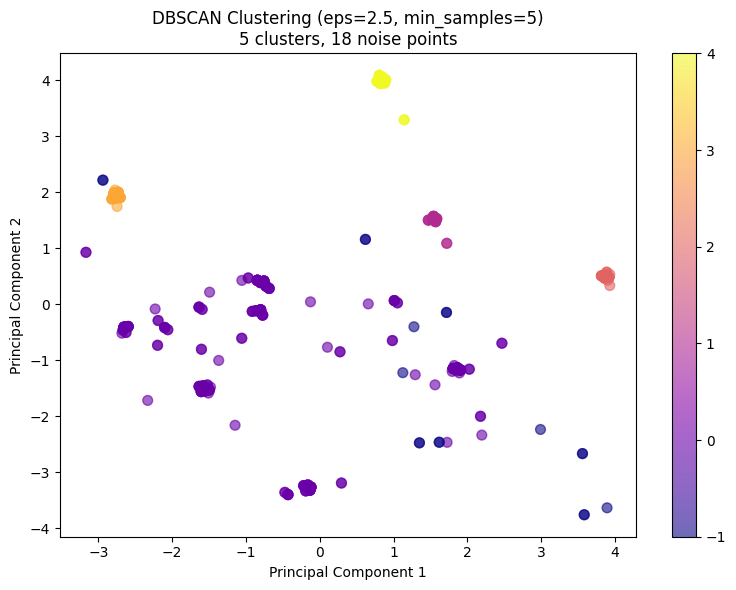

✅ DBSCAN clustering complete!


In [16]:
# ============================================================
# CLUSTERING - 3. DBSCAN
# ============================================================

from sklearn.neighbors import NearestNeighbors

# Find optimal epsilon using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.title('K-Distance Graph (k=5) - Finding Optimal Epsilon', fontsize=13)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=2.5, color='r', linestyle='--', label='Suggested epsilon=2.5')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_epsilon.png', dpi=150)
plt.show()

# Run DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points:   {n_noise}")

if n_clusters > 1:
    mask = dbscan_labels != -1
    db_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    db_db = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    db_ch = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
    print(f"\nDBSCAN Evaluation Metrics (excluding noise):")
    print(f"  Silhouette Score:        {db_silhouette:.4f}")
    print(f"  Davies-Bouldin Score:    {db_db:.4f}")
    print(f"  Calinski-Harabasz Score: {db_ch:.4f}")

# Visualize
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=dbscan_labels, cmap='plasma',
                      alpha=0.6, s=50)
plt.colorbar(scatter)
plt.title(f'DBSCAN Clustering (eps=2.5, min_samples=5)\n{n_clusters} clusters, {n_noise} noise points', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('dbscan_results.png', dpi=150)
plt.show()
print("✅ DBSCAN clustering complete!")

Spectral Clustering Evaluation Metrics:
  Silhouette Score:        0.3228
  Davies-Bouldin Score:    0.6715
  Calinski-Harabasz Score: 83.9890


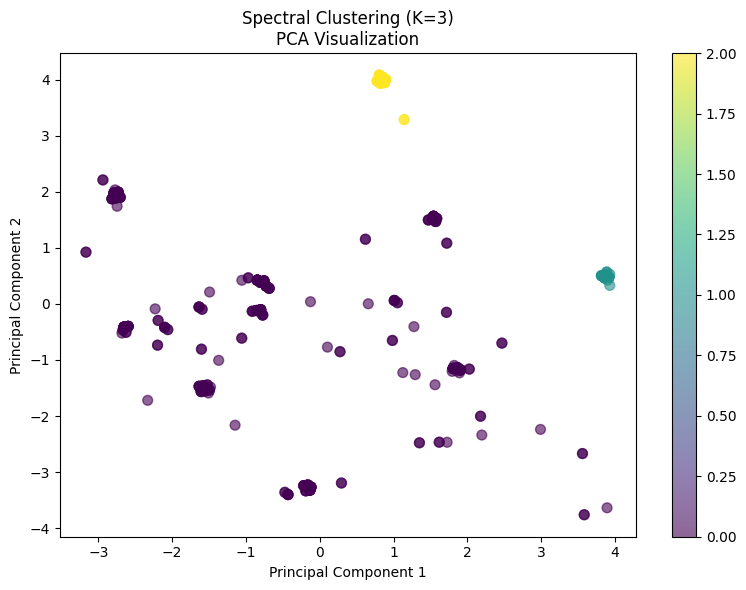

✅ Spectral clustering complete!


In [17]:
# ============================================================
# CLUSTERING - 4. SPECTRAL CLUSTERING
# ============================================================

spectral = SpectralClustering(n_clusters=3, random_state=42, 
                               affinity='rbf', n_neighbors=10)
spectral_labels = spectral.fit_predict(X_scaled)

# Evaluate
spec_silhouette = silhouette_score(X_scaled, spectral_labels)
spec_db = davies_bouldin_score(X_scaled, spectral_labels)
spec_ch = calinski_harabasz_score(X_scaled, spectral_labels)

print("Spectral Clustering Evaluation Metrics:")
print(f"  Silhouette Score:        {spec_silhouette:.4f}")
print(f"  Davies-Bouldin Score:    {spec_db:.4f}")
print(f"  Calinski-Harabasz Score: {spec_ch:.4f}")

# Visualize
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=spectral_labels, cmap='viridis',
                      alpha=0.6, s=50)
plt.colorbar(scatter)
plt.title('Spectral Clustering (K=3)\nPCA Visualization', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('spectral_results.png', dpi=150)
plt.show()
print("✅ Spectral clustering complete!")

GMM Evaluation Metrics:
  Silhouette Score:        0.2948
  Davies-Bouldin Score:    1.4124
  Calinski-Harabasz Score: 120.7958
  BIC Score:               -2990.2219  (lower is better)
  AIC Score:               -4057.6195  (lower is better)


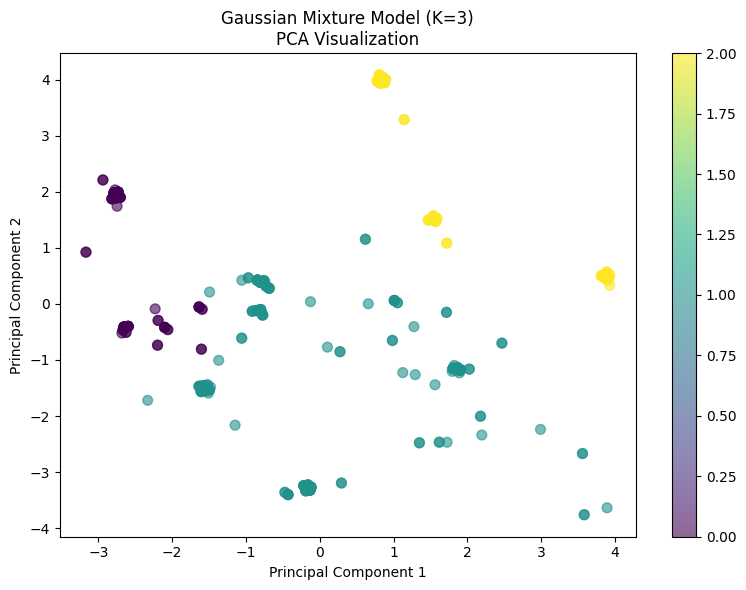

✅ GMM clustering complete!


In [19]:
# ============================================================
# CLUSTERING - 5. GAUSSIAN MIXTURE MODELS (GMM)
# ============================================================

gmm = GaussianMixture(n_components=3, random_state=42, n_init=10)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)

# Evaluate
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_db = davies_bouldin_score(X_scaled, gmm_labels)
gmm_ch = calinski_harabasz_score(X_scaled, gmm_labels)
gmm_bic = gmm.bic(X_scaled)
gmm_aic = gmm.aic(X_scaled)

print("GMM Evaluation Metrics:")
print(f"  Silhouette Score:        {gmm_silhouette:.4f}")
print(f"  Davies-Bouldin Score:    {gmm_db:.4f}")
print(f"  Calinski-Harabasz Score: {gmm_ch:.4f}")
print(f"  BIC Score:               {gmm_bic:.4f}  (lower is better)")
print(f"  AIC Score:               {gmm_aic:.4f}  (lower is better)")

# Visualize
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=gmm_labels, cmap='viridis',
                      alpha=0.6, s=50)
plt.colorbar(scatter)
plt.title('Gaussian Mixture Model (K=3)\nPCA Visualization', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('gmm_results.png', dpi=150)
plt.show()
print("✅ GMM clustering complete!")

Density Peak Clustering Evaluation Metrics:
  Silhouette Score:        0.3406
  Davies-Bouldin Score:    1.3917
  Calinski-Harabasz Score: 105.1569


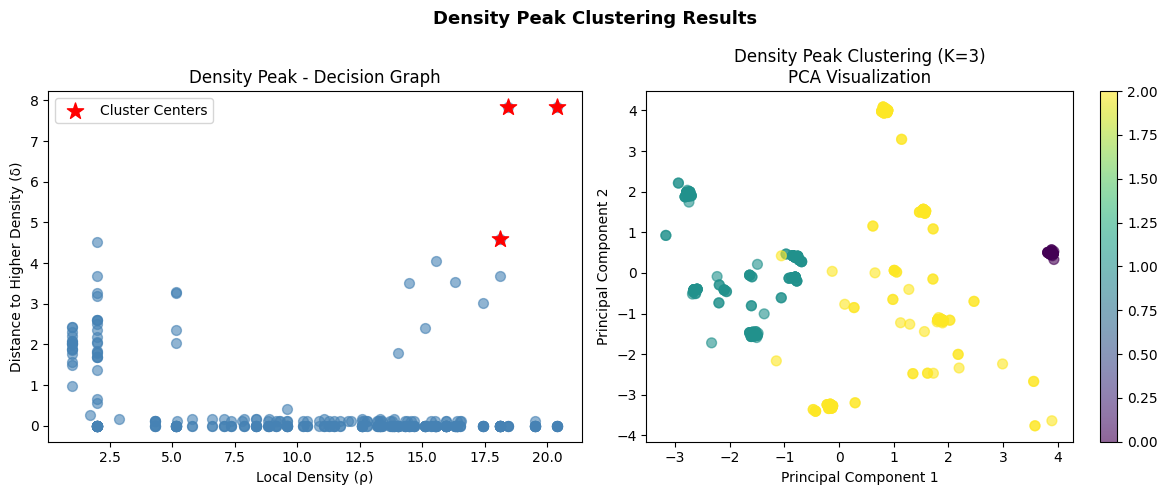

✅ Density Peak Clustering complete!


In [20]:
# ============================================================
# CLUSTERING - 6. DENSITY PEAK CLUSTERING
# ============================================================

from sklearn.metrics.pairwise import euclidean_distances

def density_peak_clustering(X, dc_percentile=2, n_clusters=3):
    dist_matrix = euclidean_distances(X)
    n = len(X)
    dc = np.percentile(dist_matrix[dist_matrix > 0], dc_percentile)
    
    # Compute local density
    rho = np.sum(np.exp(-(dist_matrix/dc)**2), axis=1)
    
    # Compute delta
    delta = np.zeros(n)
    nearest_higher = np.zeros(n, dtype=int)
    rho_sorted = np.argsort(-rho)
    
    for i in range(1, n):
        idx = rho_sorted[i]
        higher_density = rho_sorted[:i]
        dists = dist_matrix[idx, higher_density]
        min_idx = np.argmin(dists)
        delta[idx] = dists[min_idx]
        nearest_higher[idx] = higher_density[min_idx]
    delta[rho_sorted[0]] = np.max(delta)
    
    # Select cluster centers
    gamma = rho * delta
    centers = np.argsort(-gamma)[:n_clusters]
    
    # Assign labels
    labels = -np.ones(n, dtype=int)
    for i, c in enumerate(centers):
        labels[c] = i
    for idx in rho_sorted:
        if labels[idx] == -1:
            labels[idx] = labels[nearest_higher[idx]]
    
    return labels, rho, delta, gamma, centers

# Run Density Peak Clustering
dpc_labels, rho, delta, gamma, centers = density_peak_clustering(
    X_scaled, dc_percentile=2, n_clusters=3)

# Evaluate
dpc_silhouette = silhouette_score(X_scaled, dpc_labels)
dpc_db = davies_bouldin_score(X_scaled, dpc_labels)
dpc_ch = calinski_harabasz_score(X_scaled, dpc_labels)

print("Density Peak Clustering Evaluation Metrics:")
print(f"  Silhouette Score:        {dpc_silhouette:.4f}")
print(f"  Davies-Bouldin Score:    {dpc_db:.4f}")
print(f"  Calinski-Harabasz Score: {dpc_ch:.4f}")

# Decision graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(rho, delta, s=50, alpha=0.6, c='steelblue')
plt.scatter(rho[centers], delta[centers], s=150, c='red', 
            marker='*', label='Cluster Centers', zorder=5)
plt.title('Density Peak - Decision Graph', fontsize=12)
plt.xlabel('Local Density (ρ)')
plt.ylabel('Distance to Higher Density (δ)')
plt.legend()

# Cluster visualization
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=dpc_labels, cmap='viridis',
                      alpha=0.6, s=50)
plt.colorbar(scatter)
plt.title('Density Peak Clustering (K=3)\nPCA Visualization', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.suptitle('Density Peak Clustering Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dpc_results.png', dpi=150)
plt.show()
print("✅ Density Peak Clustering complete!")

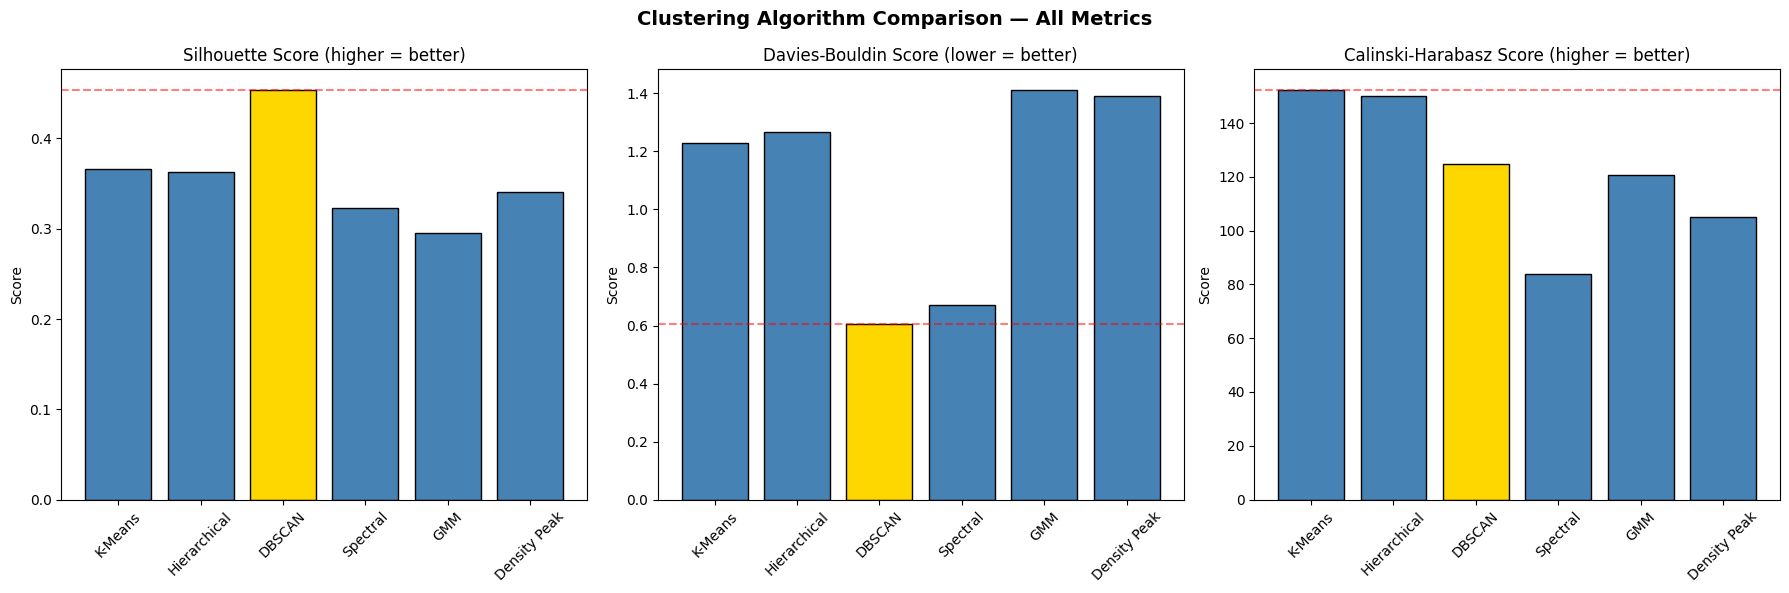


--- K-Means Cluster vs Sleep Disorder Labels ---
Sleep_Disorder  Insomnia  None  Sleep Apnea
KMeans_Cluster                             
0                      6   169            4
1                     26     7           61
2                     45    43           13

--- Hierarchical Cluster vs Sleep Disorder Labels ---
Sleep_Disorder        Insomnia  None  Sleep Apnea
Hierarchical_Cluster                             
0                           26     7           59
1                            6   166            4
2                           45    46           15

✅ Full analysis complete!


In [21]:
# ============================================================
# PHASE 7 & 8: FINAL COMPARISON + ANALYSIS
# ============================================================

# Comparison bar chart
algorithms = ['K-Means', 'Hierarchical', 'DBSCAN', 'Spectral', 'GMM', 'Density Peak']
silhouettes = [0.3661, 0.3630, 0.4539, 0.3228, 0.2948, 0.3406]
db_scores = [1.2293, 1.2671, 0.6036, 0.6715, 1.4124, 1.3917]
ch_scores = [152.34, 150.21, 124.90, 83.99, 120.80, 105.16]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['steelblue', 'steelblue', 'gold', 'steelblue', 'steelblue', 'steelblue']

axes[0].bar(algorithms, silhouettes, color=colors, edgecolor='black')
axes[0].set_title('Silhouette Score (higher = better)', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=max(silhouettes), color='red', linestyle='--', alpha=0.5)

axes[1].bar(algorithms, db_scores, color=colors, edgecolor='black')
axes[1].set_title('Davies-Bouldin Score (lower = better)', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=min(db_scores), color='red', linestyle='--', alpha=0.5)

axes[2].bar(algorithms, ch_scores, color=colors, edgecolor='black')
axes[2].set_title('Calinski-Harabasz Score (higher = better)', fontsize=12)
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=max(ch_scores), color='red', linestyle='--', alpha=0.5)

plt.suptitle('Clustering Algorithm Comparison — All Metrics', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Sleep Disorder vs K-Means clusters analysis
print("\n--- K-Means Cluster vs Sleep Disorder Labels ---")
comparison_df = pd.DataFrame({
    'KMeans_Cluster': kmeans_labels,
    'Sleep_Disorder': sleep_disorder_labels.values
})
print(pd.crosstab(comparison_df['KMeans_Cluster'], 
                  comparison_df['Sleep_Disorder']))

print("\n--- Hierarchical Cluster vs Sleep Disorder Labels ---")
comparison_df2 = pd.DataFrame({
    'Hierarchical_Cluster': hierarchical_labels,
    'Sleep_Disorder': sleep_disorder_labels.values
})
print(pd.crosstab(comparison_df2['Hierarchical_Cluster'], 
                  comparison_df2['Sleep_Disorder']))

print("\n✅ Full analysis complete!")

In [22]:
# ============================================================
# SAVE FINAL RESULTS SUMMARY
# ============================================================

results_summary = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN', 
                  'Spectral', 'GMM', 'Density Peak'],
    'Silhouette_Score': [0.3661, 0.3630, 0.4539, 
                         0.3228, 0.2948, 0.3406],
    'Davies_Bouldin_Score': [1.2293, 1.2671, 0.6036, 
                              0.6715, 1.4124, 1.3917],
    'Calinski_Harabasz_Score': [152.34, 150.21, 124.90, 
                                 83.99, 120.80, 105.16],
    'Notes': [
        'Best CH Score, clean 3 clusters',
        'Similar to K-Means, good dendrogram',
        'Best Silhouette & DB, found 5 clusters + 18 noise',
        'Struggled with tabular data',
        'Probabilistic, lowest silhouette',
        'Good decision graph, moderate performance'
    ]
})

results_summary.to_csv('clustering_results_summary.csv', index=False)
print("✅ Results summary saved!")
print("\nFinal Rankings:")
print(results_summary.to_string(index=False))

✅ Results summary saved!

Final Rankings:
   Algorithm  Silhouette_Score  Davies_Bouldin_Score  Calinski_Harabasz_Score                                             Notes
     K-Means            0.3661                1.2293                   152.34                   Best CH Score, clean 3 clusters
Hierarchical            0.3630                1.2671                   150.21               Similar to K-Means, good dendrogram
      DBSCAN            0.4539                0.6036                   124.90 Best Silhouette & DB, found 5 clusters + 18 noise
    Spectral            0.3228                0.6715                    83.99                       Struggled with tabular data
         GMM            0.2948                1.4124                   120.80                  Probabilistic, lowest silhouette
Density Peak            0.3406                1.3917                   105.16         Good decision graph, moderate performance
